# Goal: compare clustering objectives

We want the one which maximizes f1 stat (segments effect region as best as possible)

In [1]:
import numpy as np

# number of effects to model
n_repeat = 20

# p_val describes severity of effect (assuming typical F test assumptions
# ...not valid but still useful to quantify how difficult effect is)
p_val_all = np.logspace(-2.5, -1, 10)

# to speed up analysis, random voxel is chosen and dilated to this radius.
# only these voxels are included in the analysis
radius = 5

# effect size, as ratio to total voxels in experiment
effect_perc = .2

In [2]:
import gzip
import json
import shutil
import warnings
from datetime import datetime
from uuid import uuid4

import cloudpickle as pickle
from joblib import Parallel, delayed
from sklearn.metrics import f1_score, recall_score, confusion_matrix

from tqdm import tqdm
from hrba.experiment import *
from hrba.sample_effect import *

# build sample effects of various sizes

# input data
folder = '/home/matt/Dropbox/pnl_hrba/data/hcp100_lowres/image'
exp_hcp = ExperimentImageOnly.from_search(folder=folder,
                                          sbj_regex='[\d]{6}',
                                          img_glob_dict={'FA': '*_FA.nii.gz'})
exp_hcp = exp_hcp.sample_x(a=2)

seed_exp_eff_list = list()

for seed in tqdm(range(n_repeat), desc='sampling effects', total=n_repeat):
    # trim experiment to reasonable size (for speedup)
    extenter = ExtenterSphere(radius=radius)
    mask_all = extenter(mask_idx=exp_hcp.mask_idx, seed=seed)
    exp = exp_hcp.apply_mask(mask_all)

    # sample effect space
    n = exp.y.shape[2] * effect_perc
    extenter = ExtenterMinVar(n=n)
    mask_target = extenter(y=exp.y, mask_idx=exp.mask_idx, seed=seed)

    for p_val_idx, p_val in enumerate(p_val_all):
        # impose effect
        _exp, effect = exp.impose_effect(seed=seed, mask=mask_target,
                                         p_val=p_val)
        seed_exp_eff_list.append((seed, p_val_idx, _exp, effect))

sampling effects: 100%|█████████████████████████| 20/20 [00:05<00:00,  3.37it/s]


In [3]:
from sklearn.cluster import ward_tree
from sklearn.feature_extraction import grid_to_graph
import warnings

def _cluster(exp, y):
    b, num_img, num_vox = exp.y.shape
    y = y.reshape((-1, num_vox))
    connectivity = grid_to_graph(*exp.mask_idx.shape, mask=exp.mask_idx > -1)
    with warnings.catch_warnings(action="ignore"):
        children = ward_tree(X=y.T, connectivity=connectivity)[0]
    return children

def cluster_ward(exp):
    return _cluster(y=exp.y, exp=exp)

def cluster_appended(exp):
    # project into span of features of interest
    b, num_img, num_vox = exp.y.shape
    x = exp.x
    h = x.T @ np.linalg.inv(x @ x.T) @ x
    i_minus_h = h - np.eye(num_img)
    y_proj = np.einsum('bnr,ny->byr', exp.y, i_minus_h)
    y_appended = np.concatenate((exp.y, -y_proj), axis=0)
    
    return _cluster(y=y_appended, exp=exp)  

cluster_fnc_dict = {'ward': cluster_ward,
                    'appended': cluster_appended}

In [14]:
b, num_img, num_vox = exp.y.shape
x = exp.x
h = x.T @ np.linalg.inv(x @ x.T) @ x
i_minus_h = h - np.eye(num_img)
y_proj = np.einsum('bnr,ny->byr', exp.y, i_minus_h)

In [4]:
from collections import defaultdict 
from hrba.graph import get_f1

f1_max = defaultdict(lambda: np.ones((n_repeat, p_val_all.size)) * -1)

# cluster every effect, record f1 score
for seed, p_val_idx, exp, eff in tqdm(seed_exp_eff_list, desc='clustering per effect'):
    for name, cluster_fnc in cluster_fnc_dict.items():
        children = cluster_fnc(exp)

        # compute f1 score of each region
        f1 = get_f1(mask=eff.mask,
                    mask_idx=exp.mask_idx,
                    children=children)

        # record the max
        f1_max[name][seed, p_val_idx] = max(f1)        

clustering per effect: 100%|██████████████████| 200/200 [00:10<00:00, 19.74it/s]


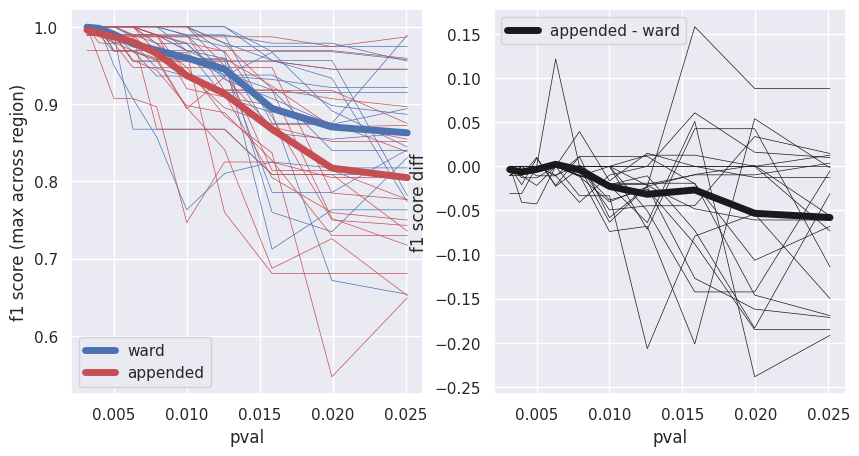

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

style_single = {'linewidth': .5,
                'zorder': 1,
                'label': '_nolegend_'}
style_mean = {'linewidth': 5,
              'zorder': 2}

color = dict(zip(cluster_fnc_dict.keys(), 'br'))

fig, ax = plt.subplots(1, 2)
plt.sca(ax[0])
for name, f1 in f1_max.items():
    # plot singles
    plt.plot(p_val_all, f1.T, c=color[name], **style_single)

    # plot mean'
    plt.plot(p_val_all, f1.mean(axis=0), c=color[name], label=name, **style_mean)

plt.xlabel('pval')
plt.ylabel('f1 score (max across region)')
plt.legend()

plt.sca(ax[1])
f1_max_diff = f1_max['appended'] - f1_max['ward']

# plot singles
plt.plot(p_val_all, f1_max_diff.T, c='k', **style_single)

# plot mean'
plt.plot(p_val_all, f1_max_diff.mean(axis=0), c='k', label='appended - ward', **style_mean)

plt.xlabel('pval')
plt.ylabel('f1 score diff')
plt.legend()
fig.set_size_inches(10, 5)